In [25]:
import numpy as np
import pandas as pd
import gymnasium as gym
from gymnasium import spaces

import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Normal

import yfinance as yf
import matplotlib.pyplot as plt

In [26]:


SEED = 0
np.random.seed(SEED)
torch.manual_seed(SEED)

TICKER = "BTC-USD"
START = "2018-01-01"
END = None

TRAIN_FRAC = 0.8

# ===== ENHANCED TRADING PARAMETERS =====
# Transaction costs
FEE = 0.0001         # REDUCED: transaction cost per unit position change (was 0.0005)

# Risk and reward parameters
KAPPA = 0.01         # REDUCED: risk penalty weight (was 0.1, now 0.01 for larger rewards)
LEVERAGE_MAX = 1.0   # max leverage (1.0 = no leverage, can extend to 2.0, 3.0, ...)

# Initial capital and liquidity
INITIAL_EQUITY = 100000.0  # starting capital in USD
MIN_CASH_RATIO = 0.05      # minimum cash must be at least 5% of equity (liquidity buffer)

# PPO hyperparameters - OPTIMIZED for trading environment
num_envs = 8         # REDUCED from 16 (more stable learning)
n_steps = 256        # INCREASED from 128 (longer trajectories for better signal)
total_updates = 3000 # INCREASED from 2000 (more training)

gamma = 0.99
gae_lambda = 0.95

lr = 1e-4            # REDUCED from 3e-4 (more stable updates)
vf_coef = 0.5
ent_coef = 0.01      # INCREASED from 0.001 (more exploration)
max_grad_norm = 1.0  # INCREASED from 0.5 (allow larger gradients)

clip_eps = 0.2
ppo_epochs = 20      # INCREASED from 10 (more policy updates per batch)
minibatch_size = 32  # REDUCED from 64 (smaller batches for stability)
target_kl = 0.05     # REDUCED from 0.1 (tighter KL control)

In [27]:
def load_ohlcv(ticker, start, end=None, interval="1d"):
    df = yf.download(
        ticker,
        start=start,
        end=end,
        interval=interval,
        auto_adjust=True,
        progress=False
    )

    df = df.dropna()

    # --- FIX MULTIINDEX ---
    if isinstance(df.columns, pd.MultiIndex):
        # keep only price level (drop ticker level)
        df.columns = df.columns.get_level_values(0)

    df.columns = [c.lower() for c in df.columns]

    return df

df = load_ohlcv(TICKER, START, END)
df.head()

,close,high,low,open,volume
Date,,,,,
2018-01-01,13657.200195,14112.200195,13154.700195,14112.200195,10291200000
2018-01-02,14982.099609,15444.599609,13163.599609,13625.000000,16846600192
2018-01-03,15201.000000,15572.799805,14844.500000,14978.200195,16871900160
2018-01-04,15599.200195,15739.700195,14522.200195,15270.700195,21783199744
2018-01-05,17429.500000,17705.199219,15202.799805,15477.200195,23840899072


# Feature engineering + toy forecasting features

In [28]:
def add_features_and_forecast(df, ewma_span=20, vol_window=20):
    """
    Add technical indicators and forecasting features.

    Features:
    - r: log returns
    - mu_hat: expected return (EWMA of returns)
    - sigma_hat: estimated volatility (rolling std)
    - r_lag1: lagged return
    - rsi: Relative Strength Index
    - macd_diff: MACD signal
    - bb_width: Bollinger Bands width (volatility signal)
    - ema_ratio: EMA 12/26 ratio (momentum)
    """
    df = df.copy()
    df["log_close"] = np.log(df["close"])
    df["r"] = df["log_close"].diff()

    # Forecast signal (toy): EWMA mean of returns
    df["mu_hat"] = df["r"].ewm(span=ewma_span, adjust=False).mean()

    # Risk estimate: rolling volatility
    df["sigma_hat"] = df["r"].rolling(vol_window).std()

    # Lag features
    df["r_lag1"] = df["r"].shift(1)

    # RSI (Relative Strength Index)
    delta = df["close"].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    rs = gain / (loss + 1e-8)
    df["rsi"] = 100 - (100 / (1 + rs))
    df["rsi"] = (df["rsi"] - 50) / 50.0  # normalize to [-1, 1]

    # MACD (Moving Average Convergence Divergence)
    ema12 = df["close"].ewm(span=12, adjust=False).mean()
    ema26 = df["close"].ewm(span=26, adjust=False).mean()
    df["macd"] = ema12 - ema26
    df["macd_signal"] = df["macd"].ewm(span=9, adjust=False).mean()
    df["macd_diff"] = df["macd"] - df["macd_signal"]
    # Normalize MACD
    macd_std = df["macd_diff"].rolling(window=20).std()
    df["macd_diff"] = df["macd_diff"] / (macd_std + 1e-8)

    # Bollinger Bands width
    sma = df["close"].rolling(window=20).mean()
    std = df["close"].rolling(window=20).std()
    bb_width = 2 * std / (sma + 1e-8)
    df["bb_width"] = bb_width / bb_width.rolling(window=50).mean()

    # EMA momentum
    ema12_ratio = ema12 / (ema26 + 1e-8)
    df["ema_ratio"] = (ema12_ratio - ema12_ratio.rolling(window=20).mean()) / (ema12_ratio.rolling(window=20).std() + 1e-8)

    df = df.dropna()
    return df

df_feat = add_features_and_forecast(df)
df_feat.head()

,close,high,low,open,volume,log_close,r,mu_hat,sigma_hat,r_lag1,rsi,macd,macd_signal,macd_diff,bb_width,ema_ratio
Date,,,,,,,,,,,,,,,,
2018-03-10,8866.000000,9531.320312,8828.469727,9350.589844,5386319872,9.089979,-0.051820,-0.014279,0.047660,-0.006135,-0.174749,-142.771367,64.817098,-1.157443,0.634059,-1.656502
2018-03-11,9578.629883,9711.889648,8607.120117,8852.780273,6296370176,9.167290,0.077311,-0.005556,0.048970,-0.051820,-0.014389,-174.964123,16.860853,-1.069560,0.647779,-1.833470
2018-03-12,9205.120117,9937.500000,8956.429688,9602.929688,6457399808,9.127515,-0.039775,-0.008815,0.049130,0.077311,-0.205392,-227.988125,-32.108942,-1.137301,0.665457,-1.935406
2018-03-13,9194.849609,9470.379883,8958.190430,9173.040039,5991139840,9.126399,-0.001116,-0.008082,0.047489,-0.039775,-0.288450,-267.752292,-79.237612,-1.145210,0.702193,-1.891597
2018-03-14,8269.809570,9355.849609,8068.589844,9214.650391,6438230016,9.020367,-0.106032,-0.017410,0.050795,-0.001116,-0.360440,-369.647612,-137.319612,-1.406847,0.805716,-2.108035


# Train/Test split (time-based)

In [29]:
n = len(df_feat)
split = int(TRAIN_FRAC * n)

df_train = df_feat.iloc[:split].reset_index(drop=True)
df_test  = df_feat.iloc[split:].reset_index(drop=True)

print(len(df_train), len(df_test))

2337 585


# Trading Environment (target position action)

In [30]:
class EnhancedTradingEnv(gym.Env):
    """
    Enhanced trading environment with full position, liquidity, and budget tracking.

    State Components:
    ================
    Market Features (normalized):
      - r: current log return
      - r_lag1: lagged return
      - mu_hat: forecasted return (EWMA)
      - sigma_hat: estimated volatility
      - rsi: relative strength index
      - macd_diff: MACD signal
      - bb_width: Bollinger Bands width
      - ema_ratio: EMA momentum

    Portfolio Features:
      - current_position: current target position a_t ∈ [-L, L]
      - cash_ratio: cash / equity (liquidity measure)
      - leverage: |a_t| / L (how much of max leverage is used)
      - drawdown: (peak_equity - current_equity) / peak_equity
      - cumulative_pnl: realized + unrealized P&L as % of initial equity
      - recent_return: short-term realized return

    Action:
    =======
      a_t ∈ [-LEVERAGE_MAX, LEVERAGE_MAX]
      Interpretation:
        - a_t = 0.5: 50% long exposure
        - a_t = -0.5: 50% short exposure
        - a_t = 1.0: 100% long (full leverage)
        - a_t = -1.0: 100% short (full leverage short)

    Reward:
    =======
      reward = pnl - transaction_cost - risk_penalty
      where:
        - pnl = pos_{t-1} * r_t (portfolio return from position)
        - transaction_cost = fee * |a_t - pos_{t-1}| (trading friction)
        - risk_penalty = kappa * pos_t^2 * sigma_t (penalize high vol positions)
    """
    metadata = {"render_modes": []}

    def __init__(self, df,
                 initial_equity=INITIAL_EQUITY,
                 fee=FEE,
                 kappa=KAPPA,
                 leverage_max=LEVERAGE_MAX,
                 min_cash_ratio=MIN_CASH_RATIO):
        super().__init__()
        self.df = df.reset_index(drop=True)
        self.initial_equity = float(initial_equity)
        self.fee = float(fee)
        self.kappa = float(kappa)
        self.leverage_max = float(leverage_max)
        self.min_cash_ratio = float(min_cash_ratio)

        # Action = target position in [-leverage_max, leverage_max]
        self.action_space = spaces.Box(
            low=-self.leverage_max,
            high=self.leverage_max,
            shape=(1,),
            dtype=np.float32
        )

        # Market features + Portfolio state features
        self.market_feature_cols = ["r", "r_lag1", "mu_hat", "sigma_hat",
                                    "rsi", "macd_diff", "bb_width", "ema_ratio"]
        # Portfolio features: position, cash_ratio, leverage, drawdown, cumulative_pnl, recent_return
        n_market_features = len(self.market_feature_cols)
        n_portfolio_features = 6
        obs_dim = n_market_features + n_portfolio_features

        self.observation_space = spaces.Box(
            low=-np.inf,
            high=np.inf,
            shape=(obs_dim,),
            dtype=np.float32
        )

        self.reset()

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.t = 1  # start from 1 because we use lagged features

        # ===== BUDGET & LIQUIDITY INITIALIZATION =====
        # Initial budget (100k USD)
        self.budget_initial = self.initial_equity
        self.budget = self.initial_equity  # available capital for trading

        # Portfolio state
        self.equity = self.initial_equity  # total portfolio value
        self.cash = self.initial_equity   # cash on hand (not invested)
        self.pos = 0.0  # target position (fraction of equity)
        self.peak_equity = self.initial_equity

        # Position tracking (in monetary terms)
        self.position_value = 0.0  # market value of current position (absolute $)
        self.position_cost = 0.0   # entry cost of current position

        # PnL tracking
        self.pnl_realized = 0.0    # cumulative realized P&L
        self.pnl_unrealized = 0.0  # current unrealized P&L
        self.last_equity = self.initial_equity

        return self._get_obs(), {}

    def _get_obs(self):
        """
        Build observation vector with improved normalization:
        - Market features (8 technical indicators)
        - Portfolio state (6 features with liquidity focus)

        Portfolio features track:
        - Liquidity: cash_ratio = cash / equity (1.0 = all cash, 0.0 = fully invested)
        - Exposure: leverage = |pos| (0.0 to 1.0)
        - Risk: drawdown from peak
        - Performance: cumulative and recent PnL
        - Position: current target position
        """
        # Market features
        market_features = self.df.loc[self.t, self.market_feature_cols].values.astype(np.float32)

        # Sanitize market features (replace NaNs and infs)
        market_features = np.nan_to_num(market_features, nan=0.0, posinf=1.0, neginf=-1.0)

        # Apply additional clipping to ensure features stay in reasonable ranges
        market_features = np.clip(market_features, -3.0, 3.0)

        # ===== LIQUIDITY & BUDGET TRACKING =====
        # 1. Current position (normalize to [-1, 1])
        current_position = np.float32(np.tanh(self.pos / 0.5))

        # 2. Liquidity ratio: how much is in CASH (not invested)
        # cash_ratio = 1.0 means 100% cash (fully liquid)
        # cash_ratio = 0.0 means 0% cash (fully invested)
        liquidity_ratio = np.float32(np.clip(self.cash / (self.equity + 1e-8), 0.0, 1.0))

        # 3. Current leverage (absolute exposure) - how much is INVESTED
        # leverage = 0.0 means no position
        # leverage = 1.0 means fully leveraged
        current_leverage = np.float32(min(abs(self.pos) / (self.leverage_max + 1e-8), 1.0))

        # 4. Drawdown from peak equity (risk metric)
        drawdown = np.float32(np.clip((self.peak_equity - self.equity) / (self.peak_equity + 1e-8), 0.0, 1.0))

        # 5. Cumulative PnL (bounded with tanh for stability)
        # Shows total profit/loss from initial budget
        cumulative_pnl = np.float32(np.tanh((self.equity - self.budget_initial) / (self.budget_initial + 1e-8)))

        # 6. Recent return (bounded)
        # Shows last step's change
        recent_return = np.float32(np.tanh((self.equity - self.last_equity) / (self.last_equity + 1e-8)))

        portfolio_features = np.array(
            [current_position, liquidity_ratio, current_leverage, drawdown, cumulative_pnl, recent_return],
            dtype=np.float32
        )

        obs = np.concatenate([market_features, portfolio_features])
        return obs

    def step(self, action):
        """
        Execute one trading step with IMPROVED reward shaping and FULL BUDGET TRACKING.

        Budget Management:
        ==================
        - Initial Budget: 100,000 USD
        - Cash: liquid funds available for trading
        - Position Value: |position| * equity (market exposure)
        - Equity = Cash + Position Value

        Liquidity Constraint:
        ====================
        - Minimum cash ratio: 5% of equity (margin requirement)
        - If position is too large, cash is penalized

        Flow:
        1. Calculate PnL from previous position
        2. Calculate transaction costs
        3. Update equity and budget
        4. Check liquidity constraints
        5. Calculate shaped reward
        6. Return obs, reward, done, info
        """
        # Clip action to valid leverage range
        a = float(np.clip(action[0], -self.leverage_max, self.leverage_max))

        # Get market data
        r_t = float(self.df.loc[self.t, "r"])
        sigma_t = float(self.df.loc[self.t, "sigma_hat"])
        price_t = float(self.df.loc[self.t, "close"])

        # Sanitize market data
        if not np.isfinite(sigma_t) or sigma_t < 0:
            sigma_t = 0.01
        if not np.isfinite(r_t):
            r_t = 0.0
        if not np.isfinite(price_t) or price_t <= 0:
            price_t = 1.0

        # ===== CALCULATE PnL FROM PREVIOUS POSITION =====
        # PnL = pos_{t-1} * r_t
        # This is the return generated by the previous position
        # Example: pos=0.5 (50% long), r_t=0.02 (2% return) => pnl=0.01 (1% portfolio return)
        pnl = self.pos * r_t

        # ===== CALCULATE TRANSACTION COST =====
        # cost = fee * |a_t - pos_{t-1}|
        # This penalizes large position changes
        # Example: switching from 0.5 to -0.5 (full reversal) costs 1.0 * fee
        position_change = abs(a - self.pos)
        transaction_cost = self.fee * position_change

        # ===== CALCULATE RISK PENALTY =====
        # Penalize high positions during high volatility
        # Encourages smaller positions when volatility is high
        risk_penalty = self.kappa * (a ** 2) * sigma_t

        # ===== IMPROVED REWARD SHAPING =====
        # Base reward: pnl - cost - risk_penalty
        base_reward = pnl - transaction_cost - risk_penalty

        # Add bonus for holding positions aligned with market momentum
        mu_hat = float(self.df.loc[self.t, "mu_hat"])
        if not np.isfinite(mu_hat):
            mu_hat = 0.0

        # Bonus if position aligns with momentum
        # (a > 0 when mu_hat > 0, or a < 0 when mu_hat < 0)
        position_alignment = np.clip(a * mu_hat, -0.01, 0.01)

        # Scaled reward with alignment bonus
        reward = base_reward + position_alignment * 0.1

        # Ensure reward is bounded to prevent training instability
        reward = np.clip(reward, -0.1, 0.1)

        # ===== UPDATE BUDGET AND PORTFOLIO =====
        # Store last equity for recent_return calculation
        self.last_equity = self.equity

        # Update equity: E_t = E_{t-1} * (1 + pnl - cost)
        # Both PnL and transaction costs affect equity
        self.equity *= float(np.exp(pnl - transaction_cost))

        # Update position
        self.pos = a

        # Update peak equity (for drawdown calculation)
        self.peak_equity = max(self.peak_equity, self.equity)

        # ===== LIQUIDITY MANAGEMENT =====
        # Calculate position value in absolute terms
        # position_value = |position| * equity
        # Example: pos=0.5, equity=100k => position_value = 50k
        position_value = abs(self.pos) * self.equity

        # Calculate available cash
        # cash = equity - position_value
        # Example: equity=100k, position_value=50k => cash=50k
        self.cash = self.equity - position_value

        # ===== LIQUIDITY CONSTRAINT: Minimum Cash Ratio =====
        # Ensure minimum cash ratio for liquidity buffer
        # MIN_CASH_RATIO = 0.05 (5%)
        # Min cash required = 0.05 * equity
        min_cash_required = self.min_cash_ratio * self.equity

        # Check if liquidity constraint is violated
        liquidity_violation = False
        if self.cash < min_cash_required:
            liquidity_violation = True
            # In a strict implementation, we could:
            # 1. Reduce position size
            # 2. Liquidate partially
            # 3. Apply penalty
            # For now, we just track it and reduce position

            # Scale down position to meet minimum cash requirement
            max_position = (self.equity - min_cash_required) / self.equity
            if abs(self.pos) > max_position:
                self.pos = np.sign(self.pos) * max_position
                position_value = abs(self.pos) * self.equity
                self.cash = self.equity - position_value

                # Apply liquidity penalty to reward
                reward = np.clip(reward - 0.05, -0.1, 0.1)

        # ===== BUDGET TRACKING =====
        # Update budget state (for diagnostics)
        self.budget = self.equity  # total available budget
        total_invested = position_value  # capital deployed in position
        cash_available = self.cash  # cash on hand

        # ===== TIME STEP AND TERMINATION =====
        self.t += 1
        terminated = (self.t >= len(self.df) - 1)
        truncated = False

        return self._get_obs(), float(reward), terminated, truncated, {
            # Core PnL components
            "pnl": pnl,
            "cost": transaction_cost,
            "risk_penalty": risk_penalty,
            "base_reward": base_reward,
            "position_alignment": position_alignment,

            # Budget & Liquidity tracking
            "equity": self.equity,
            "budget": self.budget,
            "cash": self.cash,
            "position": self.pos,
            "position_value": position_value,
            "cash_ratio": self.cash / (self.equity + 1e-8),
            "liquidity_violation": liquidity_violation,
            "min_cash_required": min_cash_required,

            # Performance metrics
            "peak_equity": self.peak_equity,
            "drawdown": (self.peak_equity - self.equity) / (self.peak_equity + 1e-8),
            "cumulative_return": (self.equity - self.budget_initial) / self.budget_initial
        }

# Vectorized env (train)

In [31]:
def make_env(df):
    def thunk():
        return EnhancedTradingEnv(
            df,
            initial_equity=INITIAL_EQUITY,
            fee=FEE,
            kappa=KAPPA,
            leverage_max=LEVERAGE_MAX,
            min_cash_ratio=MIN_CASH_RATIO
        )
    return thunk

env = gym.vector.SyncVectorEnv([make_env(df_train) for _ in range(num_envs)])
obs_dim = env.single_observation_space.shape[0]
act_dim = env.single_action_space.shape[0]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("obs_dim:", obs_dim, "act_dim:", act_dim, "device:", device)

obs_dim: 14 act_dim: 1 device: cpu


# PPO model (Gaussian policy + tanh squash + corrected logprob)

In [32]:
class ActorCritic(nn.Module):
    def __init__(self, obs_dim, act_dim):
        super().__init__()
        # Shared body with layer normalization for stability
        self.net = nn.Sequential(
            nn.Linear(obs_dim, 256),
            nn.LayerNorm(256),
            nn.Tanh(),
            nn.Linear(256, 256),
            nn.LayerNorm(256),
            nn.Tanh(),
            nn.Linear(256, 128),
            nn.Tanh()
        )

        # Actor head: output mean for position action
        self.mu = nn.Linear(128, act_dim)
        # Initialize mu weights to small values for conservative initial exploration
        nn.init.orthogonal_(self.mu.weight, gain=0.01)
        nn.init.constant_(self.mu.bias, 0.0)

        # Actor: learnable log std
        self.log_std = nn.Parameter(torch.ones(act_dim) * -0.5)  # start with moderate std

        # Critic: value function
        self.v = nn.Linear(128, 1)
        nn.init.orthogonal_(self.v.weight, gain=1.0)
        nn.init.constant_(self.v.bias, 0.0)

    def forward(self, obs):
        x = self.net(obs)
        mu = self.mu(x)
        std = torch.exp(self.log_std)
        dist = Normal(mu, std)
        value = self.v(x).squeeze(-1)
        return dist, value

def squash(u):
    return torch.tanh(u)  # maps to [-1,1]
# main formula:
# a = f(u)
# log p(a) = log p(u) - log |det(Jacobian)|
# log p(a) ist die gesuchte policy log pi(a|a)

# we have f = tanh
# a = tanh(u)
# da/du = 1 - tanh(u)^2
# da/du = 1 - a²
# we need: log |det(Jacobian)|
# we get: log |det(Jacobian)| = log(1 - tanh(u)^2)
# in code: log_det = torch.log(1.0 - torch.tanh(u).pow(2) + eps).sum(-1)

def logprob_squashed(dist, u):
    # log p(u)
    logp_u = dist.log_prob(u).sum(-1)
    # change-of-variables for tanh
    eps = 1e-6
    log_det = torch.log(1.0 - torch.tanh(u).pow(2) + eps).sum(-1)
    return logp_u - log_det

# GAE

In [33]:
def compute_gae(rewards, dones, values, last_value, gamma=0.99, lam=0.95):
    """
    rewards: [T, N]
    dones:   [T, N] (1.0 means terminal boundary for bootstrap mask)
    values:  [T, N]
    last_value: [N]
    """
    T, N = rewards.shape
    adv = torch.zeros(T, N, device=values.device)
    gae = torch.zeros(N, device=values.device)

    for t in reversed(range(T)):
        not_done = 1.0 - dones[t]
        next_value = last_value if t == T - 1 else values[t + 1]
        delta = rewards[t] + gamma * next_value * not_done - values[t]
        gae = delta + gamma * lam * not_done * gae
        adv[t] = gae

    returns = adv + values
    return returns, adv

# PPO training loop

In [34]:
model = ActorCritic(obs_dim, act_dim).to(device)
optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)

obs, _ = env.reset(seed=SEED)
obs = torch.as_tensor(obs, dtype=torch.float32, device=device)

ep_returns = np.zeros(num_envs, dtype=np.float32)
ep_history = []

print("="*70)
print(f"TRAINING CONFIGURATION")
print("="*70)
print(f"Environment: {TICKER}")
print(f"Initial Equity: ${INITIAL_EQUITY:,.0f}")
print(f"FEE: {FEE} | KAPPA: {KAPPA} | LEVERAGE_MAX: {LEVERAGE_MAX}")
print(f"Learning Rate: {lr} | Num Envs: {num_envs} | Steps: {n_steps}")
print(f"Total Updates: {total_updates} | Device: {device}")
print("="*70)
print()

for update in range(total_updates):
    # Rollout buffers
    obs_buf  = torch.zeros(n_steps, num_envs, obs_dim, device=device)
    u_buf    = torch.zeros(n_steps, num_envs, act_dim, device=device)
    logp_buf = torch.zeros(n_steps, num_envs, device=device)
    rew_buf  = torch.zeros(n_steps, num_envs, device=device)
    done_buf = torch.zeros(n_steps, num_envs, device=device)
    val_buf  = torch.zeros(n_steps, num_envs, device=device)

    for t in range(n_steps):
        obs_buf[t] = obs
        with torch.no_grad():
          dist, value = model(obs)
          u = dist.sample()
          a = squash(u)
          logp = logprob_squashed(dist, u)

        u_buf[t] = u
        logp_buf[t] = logp.detach()
        val_buf[t] = value.detach()

        # Scale actions from [-1, 1] to [-leverage_max, leverage_max]
        a_scaled = a * LEVERAGE_MAX

        next_obs, reward, terminated, truncated, infos = env.step(a_scaled.detach().cpu().numpy())
        done_env = np.logical_or(terminated, truncated)
        done_boot = terminated  # bootstrap mask (for time-limit envs you may choose terminated only)

        rew_buf[t] = torch.as_tensor(reward, dtype=torch.float32, device=device)
        done_buf[t] = torch.as_tensor(done_boot, dtype=torch.float32, device=device)

        # Episode return tracking
        ep_returns += reward
        if done_env.any():
            finished = np.where(done_env)[0]
            ep_history.extend(ep_returns[finished].tolist())
            ep_returns[finished] = 0.0

        obs = torch.as_tensor(next_obs, dtype=torch.float32, device=device)

    # Bootstrap last value
    with torch.no_grad():
        _, last_value = model(obs)

    returns, adv = compute_gae(rew_buf, done_buf, val_buf, last_value, gamma=gamma, lam=gae_lambda)

    # Flatten
    B = n_steps * num_envs
    obs_batch  = obs_buf.reshape(B, obs_dim)
    u_batch    = u_buf.reshape(B, act_dim)
    old_logp   = logp_buf.reshape(B)
    old_value  = val_buf.reshape(B).detach()  # important for value clipping
    ret_batch  = returns.reshape(B).detach()
    adv_batch  = adv.reshape(B).detach()

    # Advantage normalization
    adv_batch = (adv_batch - adv_batch.mean()) / (adv_batch.std() + 1e-8)

    idx = torch.arange(B, device=device)
    stop = False

    for _ in range(ppo_epochs):
        perm = idx[torch.randperm(B)]
        for start in range(0, B, minibatch_size):
            mb = perm[start:start + minibatch_size]

            dist, value = model(obs_batch[mb])
            logp = logprob_squashed(dist, u_batch[mb])
            entropy = dist.entropy().sum(-1)

            # Early stop by approximate KL (minibatch estimate)
            approx_kl = (old_logp[mb] - logp).mean().detach()
            if approx_kl.item() > target_kl:
                stop = True
                break

            ratio = torch.exp(logp - old_logp[mb])

            # Clipped policy objective
            unclipped = ratio * adv_batch[mb]
            clipped = torch.clamp(ratio, 1 - clip_eps, 1 + clip_eps) * adv_batch[mb]
            policy_loss = -torch.min(unclipped, clipped).mean()

            # Value loss with clipping for stability
            value_pred_clipped = old_value[mb] + torch.clamp(value - old_value[mb], -clip_eps, clip_eps)
            value_loss_unclipped = (ret_batch[mb] - value).pow(2)
            value_loss_clipped = (ret_batch[mb] - value_pred_clipped).pow(2)
            value_loss = torch.max(value_loss_unclipped, value_loss_clipped).mean()

            # Entropy bonus
            entropy_loss = -entropy.mean()

            loss = policy_loss + vf_coef * value_loss + ent_coef * entropy_loss

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
            optimizer.step()

        if stop:
            break

        # Keep std in a sane range (helps prevent wild exploration collapse/explosion)
        with torch.no_grad():
            model.log_std.clamp_(-2.0, -0.5)

    if update % 100 == 0:
        mean_100 = np.mean(ep_history[-100:]) if len(ep_history) >= 100 else np.nan
        std_100 = np.std(ep_history[-100:]) if len(ep_history) >= 100 else np.nan
        log_std = model.log_std.data.cpu().numpy()[0]

        # Get average advantage magnitude for training health check
        avg_adv = float(torch.abs(adv_batch).mean().detach().cpu().numpy())

        print(f"Update {update:4d}/{total_updates:4d} | "
              f"Return (100ep): {mean_100:8.2f}±{std_100:6.2f} | "
              f"log_std: {log_std:6.3f} | "
              f"Avg|Adv|: {avg_adv:8.4f}")

TRAINING CONFIGURATION
Environment: BTC-USD
Initial Equity: $100,000
FEE: 0.0001 | KAPPA: 0.01 | LEVERAGE_MAX: 1.0
Learning Rate: 0.0001 | Num Envs: 8 | Steps: 256
Total Updates: 3000 | Device: cpu

Update    0/3000 | Return (100ep):      nan±   nan | log_std: -0.511 | Avg|Adv|:   0.8075
Update  100/3000 | Return (100ep):      nan±   nan | log_std: -0.623 | Avg|Adv|:   0.8041
Update  200/3000 | Return (100ep):     1.51±  0.65 | log_std: -0.728 | Avg|Adv|:   0.7858
Update  300/3000 | Return (100ep):     1.86±  0.60 | log_std: -0.806 | Avg|Adv|:   0.7679
Update  400/3000 | Return (100ep):     2.37±  0.48 | log_std: -0.858 | Avg|Adv|:   0.7700
Update  500/3000 | Return (100ep):     2.81±  0.59 | log_std: -0.931 | Avg|Adv|:   0.7611
Update  600/3000 | Return (100ep):     3.41±  0.43 | log_std: -0.978 | Avg|Adv|:   0.7285
Update  700/3000 | Return (100ep):     3.34±  0.42 | log_std: -0.996 | Avg|Adv|:   0.7913
Update  800/3000 | Return (100ep):     3.45±  0.42 | log_std: -1.030 | Avg|Adv|: 

# Evaluation on test set (single env, deterministic actions)

In [35]:
def eval_policy(model, df_eval, episodes=5):
    env_eval = EnhancedTradingEnv(
        df_eval,
        initial_equity=INITIAL_EQUITY,
        fee=FEE,
        kappa=KAPPA,
        leverage_max=LEVERAGE_MAX,
        min_cash_ratio=MIN_CASH_RATIO
    )
    returns = []

    for _ in range(episodes):
        obs, _ = env_eval.reset()
        done = False
        ep_ret = 0.0

        while not done:
            obs_t = torch.as_tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)
            with torch.no_grad():
                dist, _ = model(obs_t)
                # Deterministic: use mean action (mu), then squash
                u = dist.mean
                a = squash(u)
                a_scaled = a * LEVERAGE_MAX

            obs, reward, terminated, truncated, _ = env_eval.step(a_scaled.detach().cpu().numpy()[0])
            done = terminated or truncated
            ep_ret += reward

        returns.append(ep_ret)

    return float(np.mean(returns))

test_score = eval_policy(model, df_test, episodes=10)
print("EVAL mean episode reward:", test_score)

EVAL mean episode reward: 0.11338852209122523


# Diagnostic: Check training quality

In [36]:
print("\n" + "="*70)
print("TRAINING DIAGNOSTICS")
print("="*70)
print(f"Total episodes trained: {len(ep_history)}")
if len(ep_history) > 0:
    print(f"Mean return (all episodes): {np.mean(ep_history):.4f}")
    print(f"Std return (all episodes): {np.std(ep_history):.4f}")
    print(f"Min/Max return: {np.min(ep_history):.4f} / {np.max(ep_history):.4f}")

    print(f"\nLast 100 episodes:")
    last_100 = ep_history[-100:] if len(ep_history) >= 100 else ep_history
    print(f"  Mean: {np.mean(last_100):.4f}")
    print(f"  Std: {np.std(last_100):.4f}")
    print(f"  Min/Max: {np.min(last_100):.4f} / {np.max(last_100):.4f}")

print("\nModel parameters:")
print(f"  log_std: {model.log_std.data.cpu().numpy()}")
print("="*70)


TRAINING DIAGNOSTICS
Total episodes trained: 2624
Mean return (all episodes): 4.5264
Std return (all episodes): 1.5617
Min/Max return: -1.5891 / 7.1024

Last 100 episodes:
  Mean: 5.5246
  Std: 0.3382
  Min/Max: 4.6075 / 6.3934

Model parameters:
  log_std: [-1.3225285]


# Reward Diagnostics

In [37]:
print("\n" + "="*70)
print("REWARD STRUCTURE DIAGNOSTICS")
print("="*70)

# Run a single episode and check reward components
env_diag = EnhancedTradingEnv(
    df_train[:500],  # use first 500 days for diagnosis
    initial_equity=INITIAL_EQUITY,
    fee=FEE,
    kappa=KAPPA,
    leverage_max=LEVERAGE_MAX,
    min_cash_ratio=MIN_CASH_RATIO
)

obs, _ = env_diag.reset()
rewards_list = []
pnl_list = []
cost_list = []
penalty_list = []
alignment_list = []
equity_list = []
cash_list = []
position_list = []

done = False
steps = 0
max_steps = 100

print(f"Initial Budget: ${env_diag.budget_initial:,.2f}")
print(f"Initial Equity: ${env_diag.equity:,.2f}")
print(f"Initial Cash: ${env_diag.cash:,.2f}")
print()

while not done and steps < max_steps:
    # Random action for diagnostic
    a = np.random.uniform(-LEVERAGE_MAX, LEVERAGE_MAX)
    obs, reward, terminated, truncated, info = env_diag.step(np.array([a]))
    done = terminated or truncated

    rewards_list.append(reward)
    pnl_list.append(info.get('pnl', 0.0))
    cost_list.append(info.get('cost', 0.0))
    penalty_list.append(info.get('risk_penalty', 0.0))
    alignment_list.append(info.get('position_alignment', 0.0))
    equity_list.append(info.get('equity', 0.0))
    cash_list.append(info.get('cash', 0.0))
    position_list.append(info.get('position', 0.0))
    steps += 1

print(f"Episode steps: {steps}")
print(f"\nReward components (mean across {steps} steps):")
print(f"  PnL:       {np.mean(pnl_list):10.6f} (range: [{np.min(pnl_list):.6f}, {np.max(pnl_list):.6f}])")
print(f"  Cost:      {np.mean(cost_list):10.6f} (range: [{np.min(cost_list):.6f}, {np.max(cost_list):.6f}])")
print(f"  Penalty:   {np.mean(penalty_list):10.6f} (range: [{np.min(penalty_list):.6f}, {np.max(penalty_list):.6f}])")
print(f"  Alignment: {np.mean(alignment_list):10.6f} (range: [{np.min(alignment_list):.6f}, {np.max(alignment_list):.6f}])")
print(f"  Final Reward: {np.mean(rewards_list):10.6f} (range: [{np.min(rewards_list):.6f}, {np.max(rewards_list):.6f}])")

print(f"\nBudget & Liquidity (mean across {steps} steps):")
print(f"  Equity:    ${np.mean(equity_list):12,.2f} (range: [${np.min(equity_list):,.2f}, ${np.max(equity_list):,.2f}])")
print(f"  Cash:      ${np.mean(cash_list):12,.2f} (range: [${np.min(cash_list):,.2f}, ${np.max(cash_list):,.2f}])")
print(f"  Position:  {np.mean(position_list):10.4f} (range: [{np.min(position_list):.4f}, {np.max(position_list):.4f}])")

print(f"\nReward statistics:")
print(f"  Positive rewards: {(np.array(rewards_list) > 0).sum()} / {len(rewards_list)}")
print(f"  Zero rewards:     {(np.array(rewards_list) == 0).sum()} / {len(rewards_list)}")
print(f"  Negative rewards: {(np.array(rewards_list) < 0).sum()} / {len(rewards_list)}")

print(f"\nFinal Episode State:")
print(f"  Final Equity: ${equity_list[-1]:,.2f}")
print(f"  Final Cash:   ${cash_list[-1]:,.2f}")
print(f"  Final Position: {position_list[-1]:.4f}")
print(f"  Return: {(equity_list[-1] / env_diag.budget_initial - 1) * 100:.2f}%")

print("="*70)
print()


REWARD STRUCTURE DIAGNOSTICS
Initial Budget: $100,000.00
Initial Equity: $100,000.00
Initial Cash: $100,000.00

Episode steps: 100

Reward components (mean across 100 steps):
  PnL:        -0.000572 (range: [-0.072434, 0.068080])
  Cost:        0.000068 (range: [0.000001, 0.000176])
  Penalty:     0.000126 (range: [0.000001, 0.000462])
  Alignment:  -0.000182 (range: [-0.010000, 0.010000])
  Final Reward:  -0.004785 (range: [-0.076252, 0.067950])

Budget & Liquidity (mean across 100 steps):
  Equity:    $   92,509.13 (range: [$85,203.49, $105,723.01])
  Cash:      $   46,270.65 (range: [$4,296.38, $94,895.43])
  Position:     -0.0541 (range: [-0.9500, 0.9500])

Reward statistics:
  Positive rewards: 37 / 100
  Zero rewards:     0 / 100
  Negative rewards: 63 / 100

Final Episode State:
  Final Equity: $93,798.50
  Final Cash:   $4,689.92
  Final Position: -0.9500
  Return: -6.20%




EQUITY CURVE ANALYSIS WITH BUDGET TRACKING

--- INITIAL STATE ---
Initial Budget: $100,000.00
Initial Equity: $100,000.00
Initial Cash: $100,000.00

--- FINAL STATE ---
Final Equity: $107,888.14
Total Return: 7.89%
Absolute Gain/Loss: $7,888.14
Peak Equity: $115,619.80
Lowest Equity: $77,057.22
Max Drawdown: 26.50%

--- POSITION STATISTICS ---
Mean position: -0.0019
Std position: 0.6524
Min/Max position: -0.9243 / 0.8737
Number of position changes: 488

--- TRADING STATISTICS ---
Total days: 584
Days with long position (>0): 286
Days with short position (<0): 295
Days with flat position (~0): 3
Total transaction costs: $0.01
As % of initial equity: 0.0000%

--- PnL ANALYSIS ---
Positive PnL days: 300 / 583 (51.5%)
Negative PnL days: 282 / 583 (48.4%)
Mean daily PnL: 0.0153%
Std daily PnL: 1.6732%
Max daily gain: 10.3103%
Max daily loss: -12.8709%


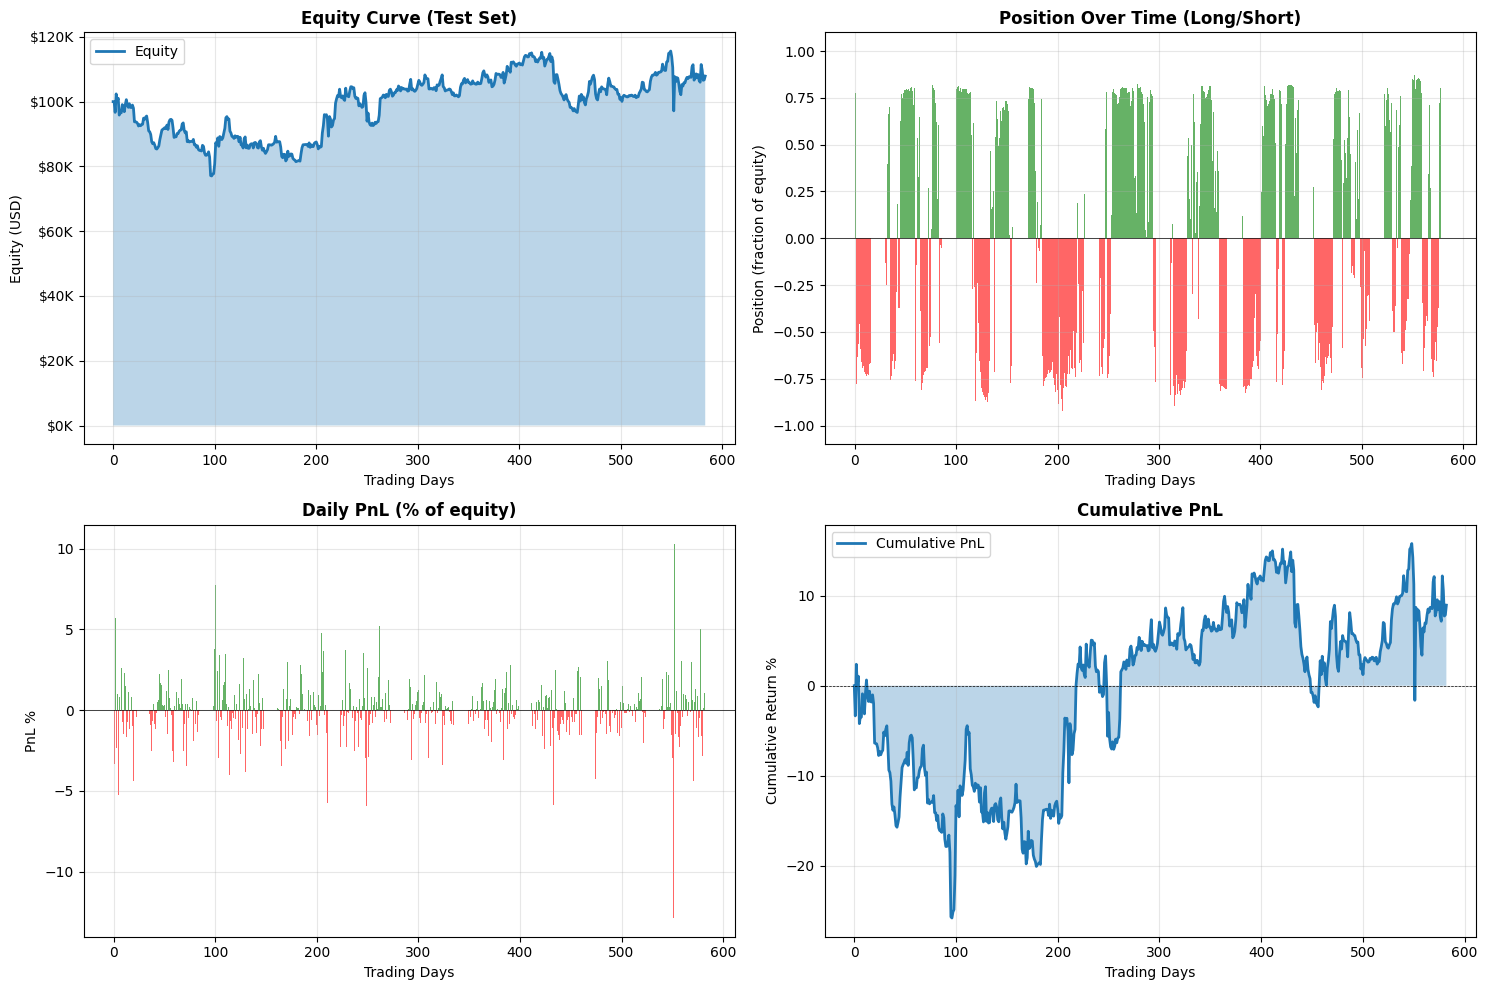


Visualization saved to 'enhanced_trading_analysis.png'


In [38]:
def run_equity_curve(model, df_eval):
    env_eval = EnhancedTradingEnv(
        df_eval,
        initial_equity=INITIAL_EQUITY,
        fee=FEE,
        kappa=KAPPA,
        leverage_max=LEVERAGE_MAX,
        min_cash_ratio=MIN_CASH_RATIO
    )
    obs, _ = env_eval.reset()
    done = False

    equity = [env_eval.equity]
    pos_hist = [env_eval.pos]
    pnl_hist = []
    cost_hist = []

    while not done:
        obs_t = torch.as_tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)
        with torch.no_grad():
            dist, _ = model(obs_t)
            u = dist.mean
            a = squash(u)
            a_scaled = a * LEVERAGE_MAX

        obs, reward, terminated, truncated, info = env_eval.step(a_scaled.detach().cpu().numpy()[0])
        done = terminated or truncated
        equity.append(env_eval.equity)
        pos_hist.append(env_eval.pos)
        pnl_hist.append(info.get('pnl', 0.0))
        cost_hist.append(info.get('cost', 0.0))

    return np.array(equity), np.array(pos_hist), np.array(pnl_hist), np.array(cost_hist)

equity, pos_hist, pnl_hist, cost_hist = run_equity_curve(model, df_test)

# Print detailed statistics
print("\n" + "="*60)
print("EQUITY CURVE ANALYSIS WITH BUDGET TRACKING")
print("="*60)
print(f"\n--- INITIAL STATE ---")
print(f"Initial Budget: ${INITIAL_EQUITY:,.2f}")
print(f"Initial Equity: ${equity[0]:,.2f}")
print(f"Initial Cash: ${INITIAL_EQUITY:,.2f}")

print(f"\n--- FINAL STATE ---")
print(f"Final Equity: ${equity[-1]:,.2f}")
print(f"Total Return: {(equity[-1] / equity[0] - 1) * 100:.2f}%")
print(f"Absolute Gain/Loss: ${equity[-1] - equity[0]:,.2f}")
print(f"Peak Equity: ${np.max(equity):,.2f}")
print(f"Lowest Equity: ${np.min(equity):,.2f}")
print(f"Max Drawdown: {(1 - np.min(equity) / np.max(equity[:len(equity)//2])) * 100:.2f}%")

print(f"\n--- POSITION STATISTICS ---")
print(f"Mean position: {np.mean(pos_hist):.4f}")
print(f"Std position: {np.std(pos_hist):.4f}")
print(f"Min/Max position: {np.min(pos_hist):.4f} / {np.max(pos_hist):.4f}")
print(f"Number of position changes: {np.sum(np.abs(np.diff(pos_hist)) > 0.01)}")

print(f"\n--- TRADING STATISTICS ---")
print(f"Total days: {len(pos_hist)}")
print(f"Days with long position (>0): {np.sum(pos_hist > 0.01)}")
print(f"Days with short position (<0): {np.sum(pos_hist < -0.01)}")
print(f"Days with flat position (~0): {np.sum(np.abs(pos_hist) <= 0.01)}")
print(f"Total transaction costs: ${np.sum(cost_hist):,.2f}")
print(f"As % of initial equity: {np.sum(cost_hist) / INITIAL_EQUITY * 100:.4f}%")

print(f"\n--- PnL ANALYSIS ---")
print(f"Positive PnL days: {(pnl_hist > 0).sum()} / {len(pnl_hist)} ({(pnl_hist > 0).sum()/len(pnl_hist)*100:.1f}%)")
print(f"Negative PnL days: {(pnl_hist < 0).sum()} / {len(pnl_hist)} ({(pnl_hist < 0).sum()/len(pnl_hist)*100:.1f}%)")
print(f"Mean daily PnL: {np.mean(pnl_hist)*100:.4f}%")
print(f"Std daily PnL: {np.std(pnl_hist)*100:.4f}%")
print(f"Max daily gain: {np.max(pnl_hist)*100:.4f}%")
print(f"Max daily loss: {np.min(pnl_hist)*100:.4f}%")

print("="*60)

# Create comprehensive visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Equity Curve
ax = axes[0, 0]
ax.plot(equity, linewidth=2, label='Equity')
ax.fill_between(range(len(equity)), equity, alpha=0.3)
ax.set_title('Equity Curve (Test Set)', fontsize=12, fontweight='bold')
ax.set_xlabel('Trading Days')
ax.set_ylabel('Equity (USD)')
ax.grid(True, alpha=0.3)
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e3:.0f}K'))

# 2. Position History
ax = axes[0, 1]
colors = ['green' if p > 0 else 'red' for p in pos_hist]
ax.bar(range(len(pos_hist)), pos_hist, color=colors, alpha=0.6)
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax.set_title('Position Over Time (Long/Short)', fontsize=12, fontweight='bold')
ax.set_xlabel('Trading Days')
ax.set_ylabel('Position (fraction of equity)')
ax.set_ylim([-1.1, 1.1])
ax.grid(True, alpha=0.3)

# 3. Daily PnL
ax = axes[1, 0]
colors_pnl = ['green' if p > 0 else 'red' for p in pnl_hist]
ax.bar(range(len(pnl_hist)), pnl_hist * 100, color=colors_pnl, alpha=0.6)
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax.set_title('Daily PnL (% of equity)', fontsize=12, fontweight='bold')
ax.set_xlabel('Trading Days')
ax.set_ylabel('PnL %')
ax.grid(True, alpha=0.3)

# 4. Cumulative PnL
ax = axes[1, 1]
cumulative_pnl = np.cumsum(pnl_hist) * 100
ax.plot(cumulative_pnl, linewidth=2, label='Cumulative PnL')
ax.fill_between(range(len(cumulative_pnl)), cumulative_pnl, alpha=0.3)
ax.axhline(y=0, color='black', linestyle='--', linewidth=0.5)
ax.set_title('Cumulative PnL', fontsize=12, fontweight='bold')
ax.set_xlabel('Trading Days')
ax.set_ylabel('Cumulative Return %')
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.savefig('/home/isc-den/cas-artificial-intelligence/15_project_teil_b/Agent/enhanced_trading_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nVisualization saved to 'enhanced_trading_analysis.png'")